<h1 style="text-align:center;">Celiac TCRs</h1>

In [78]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [80]:
def normalize_tissue(val):
    if pd.isna(val):
        return pd.NA

    # split on ; , and "and"
    parts = re.split(r';|,| and ', val.lower())
    parts = [p.strip() for p in parts if p.strip()]

    has_biopsy = any(p in biopsy_terms for p in parts)
    has_blood = any(p in blood_terms for p in parts)

    if has_biopsy and has_blood:
        return 'blood;biopsy'
    elif has_biopsy:
        return 'biopsy'
    elif has_blood:
        return 'blood'
    else:
        return pd.NA  # or keep original if you prefer
    
def split_and_align(row, cols, sep=';'):
    parts = {}
    lengths = {}

    for col in cols:
        val = row[col]
        if pd.isna(val):
            parts[col] = [pd.NA]
        else:
            parts[col] = [x.strip() for x in str(val).split(sep)]
        lengths[col] = len(parts[col])

    max_len = max(lengths.values())

    for col in cols:
        if lengths[col] == 1 and max_len > 1:
            parts[col] = parts[col] * max_len
        elif lengths[col] not in (1, max_len):
            raise ValueError(
                f"Row {row.name}: incompatible counts {lengths} for columns {cols}"
            )

    # duplicate the whole row max_len times
    out = pd.DataFrame([row.to_dict()] * max_len)

    # replace only the aligned columns
    for col in cols:
        out[col] = parts[col]

    return out



# Overview

## Celiac specific

In [97]:
df = pd.read_csv('celiac_specific_CD4_2026-02-26.csv')
df = df[["Subset","clonotype_id","TRAV","TRAJ","cdr3_TRA","TRBV","TRBJ","cdr3_TRB","Tissue","general_condition", "Epitope.peptide"]]

# clean tissue annotation
biopsy_terms = {'gut', 'duodenum', 'bulbus', 'small intestine'}
blood_terms = {'blood', 'pbmc'}

df['Tissue'] = df['Tissue'].apply(normalize_tissue)

# fix columns with double values
cols = ['Tissue']
df = pd.concat(
    [split_and_align(row, cols) for _, row in df.iterrows()],
    ignore_index=True
)

df.to_csv('celiac_specific_CD4_clean.csv', index=False)

Text(0.5, 1.0, 'CELIA specific n(TCRs) = 357')

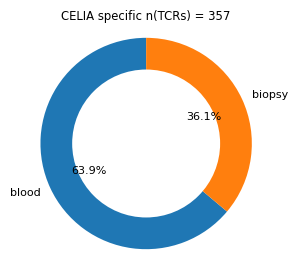

In [86]:
df = pd.read_csv('celiac_specific_CD4_clean.csv') 

fig, ax = plt.subplots(1,1,figsize=(3,3))

# count occurrences
counts = df['Tissue'].value_counts()
wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

# create donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.axis('equal')  # keep circle shape
plt.title(f"CELIA specific n(TCRs) = {len(df)}", fontsize='small')

## Repertoire

In [43]:
df = pd.read_csv('celiac_CD4_CD8_2026-02-26.csv')

df = df[["Subset","clonotype_id","TRAV","TRAJ","cdr3_TRA","TRBV","TRBJ","cdr3_TRB","Tissue","general_condition"]]

# fix columns with double values
cols = ['Tissue', 'general_condition']
df = pd.concat(
    [split_and_align(row, cols) for _, row in df.iterrows()],
    ignore_index=True
)

df['Tissue'] = np.where(df['Tissue'] == 'gut', 'biopsy', df['Tissue'])
df.to_csv('celiac_CD4_CD8_clean.csv', index=False)

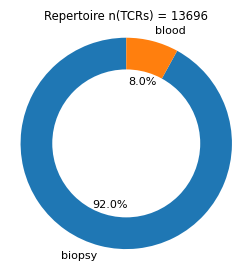

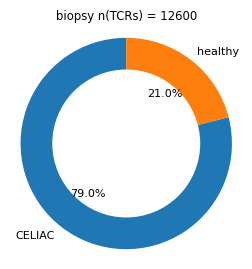

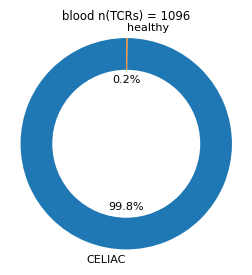

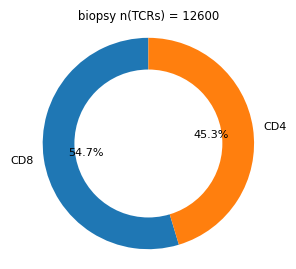

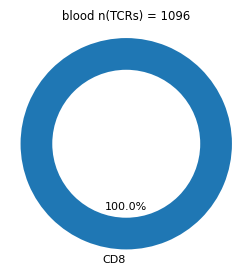

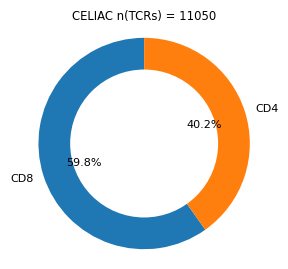

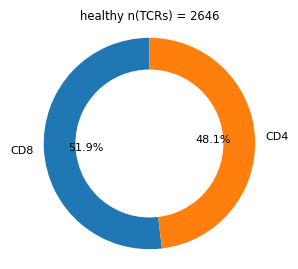

In [87]:
df = pd.read_csv('celiac_CD4_CD8_clean.csv') 

fig, ax = plt.subplots(1,1,figsize=(3,3))

# count occurrences
counts = df['Tissue'].value_counts()
wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

# create donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.axis('equal')  # keep circle shape
plt.title(f"Repertoire n(TCRs) = {len(df)}", fontsize='small')

tissues = np.unique(df['Tissue'])

for tissue in tissues:
    fig, ax = plt.subplots(1,1,figsize=(3,3))
    
    # count occurrences
    df_tissue = df[df['Tissue'] == tissue]
    counts = df_tissue['general_condition'].value_counts()
    wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

    # create donut hole
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    ax.axis('equal')  # keep circle shape
    plt.title(f"{tissue} n(TCRs) = {len(df_tissue)}", fontsize='small')


# =======================================
for tissue in tissues:
    fig, ax = plt.subplots(1,1,figsize=(3,3))
    
    # count occurrences
    df_tissue = df[df['Tissue'] == tissue]
    counts = df_tissue['Subset'].value_counts()
    wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

    # create donut hole
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    ax.axis('equal')  # keep circle shape
    plt.title(f"{tissue} n(TCRs) = {len(df_tissue)}", fontsize='small')

# =======================================
df = pd.read_csv('celiac_CD4_CD8_clean.csv') 
tissues = np.unique(df['general_condition'])

for tissue in tissues:
    fig, ax = plt.subplots(1,1,figsize=(3,3))
    
    # count occurrences
    df_tissue = df[df['general_condition'] == tissue]
    counts = df_tissue['Subset'].value_counts()
    wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

    # create donut hole
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    ax.axis('equal')  # keep circle shape
    plt.title(f"{tissue} n(TCRs) = {len(df_tissue)}", fontsize='small')


# Motif input

# 

In [91]:
# repertoire data
df = pd.read_csv('celiac_CD4_CD8_clean.csv') 

for name, df_motif in df.groupby('general_condition'):
    df_motif.to_csv(f'celiac_CD4_CD8_{name}.csv', index=False)
    print(len(df_motif))


11050
2646


In [93]:
# celiac specific TCRs
df = pd.read_csv('celiac_specific_CD4_clean.csv') 

lst = []
for name, df_motif in df.groupby('Tissue'):
    df_motif['model'] = name
    lst.append(df_motif)

df_motif = pd.concat(lst)
df_motif.to_csv(f'celiac_specific_CD4_tissue.csv', index=False)


In [95]:
df = pd.read_csv('celiac_specific_CD4_clean.csv') 
df.head()

,Subset,clonotype_id,TRAV,TRAJ,cdr3_TRA,TRBV,TRBJ,cdr3_TRB,Tissue,general_condition
0,CD4,CEL2,TRAV8-6,TRAJ28,CAMREGRGAGSYQLTF,TRBV4-2,TRBJ2-3,CASSFPQVTDTQYF,biopsy,CELIAC
1,CD4,CEL3,TRAV8-6,TRAJ54,CIAFQGAQKLVF,TRBV7-2,TRBJ2-3,CASSFRALAADTQYF,biopsy,CELIAC
2,CD4,CEL7,TRAV13-2,TRAJ40,CAMSVLSGTYKYIF,TRBV4-2,TRBJ2-5,CASSHVDRGGETQYF,biopsy,CELIAC
3,CD4,CEL8,TRAV14/DV4,TRAJ40,CAASEGDSGTYKYIF,TRBV19,TRBJ2-1,CASSINALVGEQFF,biopsy,CELIAC
4,CD4,CEL9,TRAV12-2,TRAJ17,CLVGEAAGNKLTF,TRBV7-2,TRBJ2-7,CASSIRTSGDHEQYF,biopsy,CELIAC
